In [1]:
from IPython.display import HTML, display

organization_name = "DataVine Analytics"
group_name = "Group 15 Project"

projects = [
    "🍷 Wine Classification",
    "🐔 Agricultural Feed Recommendation",
    "🚔 Regional Crime Pattern Analysis"
]

team_members = [
    "Benedict Onyango",
    "Francis K. Mwangi",
    "Allan Abok",
    "Shem",
    "Sandra"
]

display(HTML(f"""
<div style="
    background: linear-gradient(135deg, #0F172A, #1E3A8A);
    color: white;
    padding: 30px;
    border-radius: 15px;
    text-align: center;
    font-family: Arial;
    box-shadow: 0px 4px 10px rgba(0,0,0,0.3);
">

<h1 style="font-size:42px;">📊 DataVine Analytics</h1>

<h2 style="font-size:28px;">Group 15 Projects</h2>

<h3 style="font-size:24px;">Summative Machine Learning Lab - Module 4</h3>

<h3 style="font-size:22px;">Projects</h3>

<div style="font-size:20px;">
🍷 Wine Classification<br>
🐔 Agricultural Feed Recommendation<br>
🚔 Regional Crime Pattern Analysis
</div>

<h3 style="font-size:22px;">Team Members</h3>

<div style="font-size:19px;">
1. Benedict Onyango<br>
2. Francis K. Mwangi<br>
3. Allan Abok<br>
4. Shem<br>
5. Sandra
</div>

<h3 style="font-size:20px;">Course: Data Science</h3>
<h3 style="font-size:20px;">Date: August 2026</h3>

</div>
"""))

### OVERVIEW

This notebook applies machine learning techniques to three datasets representing different business problems:

Wine Dataset — k-Nearest Neighbors classification with PCA and hyperparameter tuning.
Chickwts Dataset — recommendation system using PCA and cosine similarity.
USArrests Dataset — clustering using K-Means and Gaussian Mixture Models.

The objective is to follow a complete machine learning workflow involving data preparation, exploratory analysis, preprocessing, dimensionality reduction, model development, evaluation, visualization, and interpretation.

In [2]:
#Importing necesary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
import warnings
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
print("Libraries imported successfully!")

Libraries imported successfully!


# Part 1. Wine Classification System

## Business Objective

A premium wine distributor wants to automatically classify wine varieties using measurable chemical properties.

A k-Nearest Neighbors (k-NN) classification model will be developed. PCA will be used to reduce dimensionality while retaining 95% of the variance, and GridSearchCV will be used to identify the optimal k-NN hyperparameters.


In [3]:
#Loading data
wine = pd.read_csv("wine.csv")
print("Wine dataset loaded successfully.")
print("Shape:", wine.shape)
wine.head()

Wine dataset loaded successfully.
Shape: (178, 14)


,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


Confirm:

Number of observations

Number of variables

Column names

Data types

Missing values

Duplicate records

In [4]:
# Check data shape,column names , missing values and duplicate rows
print("Dataset shape:")
print(wine.shape)

print("\nColumn names:")
print(wine.columns.tolist())

print("\nData types:")
print(wine.dtypes)

print("\nMissing values:")
print(wine.isnull().sum())

print("\nDuplicate rows:")
print(wine.duplicated().sum())

Dataset shape:
(178, 14)

Column names:
['Wine', 'Alcohol', 'Malic.acid', 'Ash', 'Acl', 'Mg', 'Phenols', 'Flavanoids', 'Nonflavanoid.phenols', 'Proanth', 'Color.int', 'Hue', 'OD', 'Proline']

Data types:
Wine                      int64
Alcohol                 float64
Malic.acid              float64
Ash                     float64
Acl                     float64
Mg                        int64
Phenols                 float64
Flavanoids              float64
Nonflavanoid.phenols    float64
Proanth                 float64
Color.int               float64
Hue                     float64
OD                      float64
Proline                   int64
dtype: object

Missing values:
Wine                    0
Alcohol                 0
Malic.acid              0
Ash                     0
Acl                     0
Mg                      0
Phenols                 0
Flavanoids              0
Nonflavanoid.phenols    0
Proanth                 0
Color.int               0
Hue                     0
OD   

In [5]:
#Finding the target Column that contains Wine Variety/Class
wine.head()

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [6]:
#To check Target
for column in wine.columns:
    print(column, ":", wine[column].nunique(), "unique values")

Wine : 3 unique values
Alcohol : 126 unique values
Malic.acid : 133 unique values
Ash : 79 unique values
Acl : 63 unique values
Mg : 53 unique values
Phenols : 97 unique values
Flavanoids : 132 unique values
Nonflavanoid.phenols : 39 unique values
Proanth : 101 unique values
Color.int : 132 unique values
Hue : 78 unique values
OD : 122 unique values
Proline : 121 unique values


In [7]:
#Check target distribution
target_column = "Wine"
print(wine[target_column].value_counts())

Wine
2    71
1    59
3    48
Name: count, dtype: int64


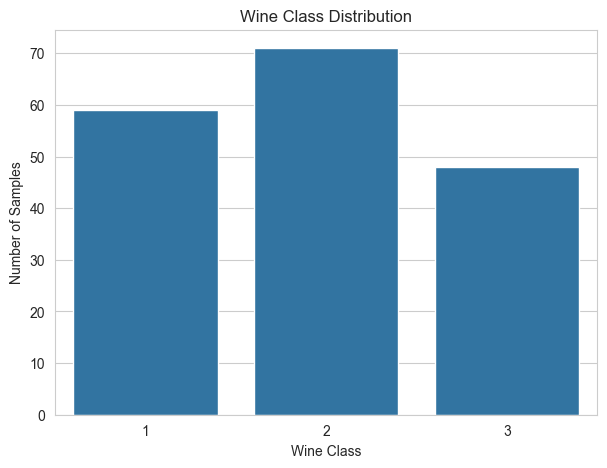

In [8]:
#Visualize
plt.figure(figsize=(7, 5))
sns.countplot(
    data=wine,
    x=target_column
)
plt.title("Wine Class Distribution")
plt.xlabel("Wine Class")
plt.ylabel("Number of Samples")
plt.show()

In [9]:
#Separate X and y
X = wine.drop(columns=["Wine"])
y = wine["Wine"]
print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:")
print(X.columns.tolist())

Features shape: (178, 13)
Target shape: (178,)

Feature columns:
['Alcohol', 'Malic.acid', 'Ash', 'Acl', 'Mg', 'Phenols', 'Flavanoids', 'Nonflavanoid.phenols', 'Proanth', 'Color.int', 'Hue', 'OD', 'Proline']


In [10]:
#Encoding the target
#Converting categorical target labels into numeric values.originally it was 1,2,3 after encodning it becomes 0,1 and 2
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print("Original wine classes:")
print(label_encoder.classes_)
print("\nEncoded classes:")
print(np.unique(y_encoded))

Original wine classes:
[1 2 3]

Encoded classes:
[0 1 2]


In [11]:
#Check Missing values 
print("Total missing values:", X.isnull().sum().sum())
print("Total duplicate rows:", wine.duplicated().sum())

Total missing values: 0
Total duplicate rows: 0


In [12]:
#Examining Numerical values 
#Proline has values in the hundreds/thousands, while some other variables have much smaller ranges.
#As such,standardization was applied  before PCA and k-NN.
X.describe().T

,count,mean,std,min,25%,50%,75%,max
Alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
Malic.acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
Ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
Acl,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
Mg,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
Phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
Flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
Nonflavanoid.phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
Proanth,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
Color.int,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


In [13]:
#Split the data
# Creating training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (142, 13)
Testing set: (36, 13)


In [14]:
#Creating Scaler to stardadize the data 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Standardization completed.")

Standardization completed.


In [15]:
#Applying  PCA with 95% variance
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
print("Original features:", X_train.shape[1])
print("PCA components:", X_train_pca.shape[1])

Original features: 13
PCA components: 10


In [16]:
#Checking the variance
print("Explained variance ratio:")
print(pca.explained_variance_ratio_)
print("\nTotal explained variance:")
print(pca.explained_variance_ratio_.sum())

Explained variance ratio:
[0.35792104 0.19270671 0.11019835 0.07272276 0.06721919 0.05131943
 0.04377423 0.02500853 0.0227943  0.01877102]

Total explained variance:
0.9624355601767978


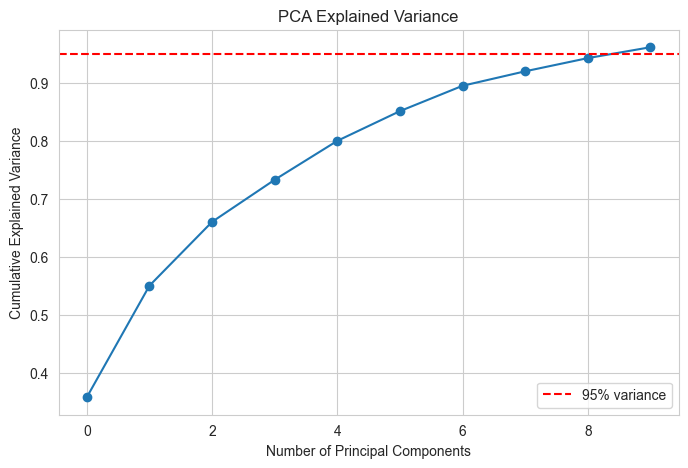

In [17]:
#Ploting the variance
plt.figure(figsize=(8, 5))
plt.plot(
    np.cumsum(pca.explained_variance_ratio_),
    marker="o"
)
plt.axhline(
    y=0.95,
    color="red",
    linestyle="--",
    label="95% variance"
)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#Tuning the KNN-Model
knn = KNeighborsClassifier()
param_grid = {
    "n_neighbors": range(1, 21),
    "metric": ["euclidean", "manhattan", "minkowski"]
}
grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
grid_search.fit(X_train_pca, y_train)
print("Best parameters:")
print(grid_search.best_params_)
print("\nBest cross-validation accuracy:")
print(grid_search.best_score_)

In [ ]:
#Training the optimized model
best_knn = grid_search.best_estimator_
best_knn.fit(X_train_pca, y_train)
y_pred = best_knn.predict(X_test_pca)
print("Optimized k-NN model trained successfully.")

Optimized k-NN model trained successfully.


In [ ]:
#Calculating or getting the Model Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Accuracy: 1.0000
Test Accuracy: 100.00%


In [ ]:
#Classification Report
print(classification_report(
    y_test,
    y_pred,
    target_names=[str(c) for c in label_encoder.classes_]
))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        12
           2       1.00      1.00      1.00        14
           3       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



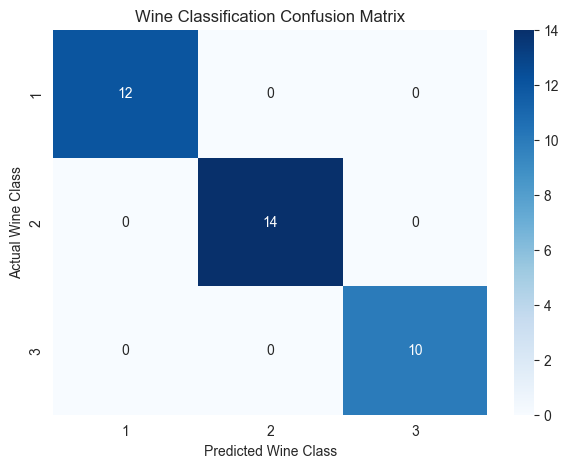

In [ ]:
#Confusion Matrix-Visualizing Classification Results above
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("Wine Classification Confusion Matrix")
plt.xlabel("Predicted Wine Class")
plt.ylabel("Actual Wine Class")
plt.show()

## Wine Classification Results & Interpretation
The Wine dataset contained 178 observations, 13 chemical features, and three wine classes. There were no missing values or duplicate observations.
The numerical features were standardized, and PCA reduced the 13 features to 10 components while retaining 95% of the variance.
GridSearchCV identified k = 18 and the Euclidean distance metric as the best k-NN parameters, achieving 97.91% cross-validation accuracy.
The optimized k-NN model achieved 100% test accuracy, correctly classifying all test observations with no misclassifications.
Overall, PCA combined with optimized k-NN provided highly accurate wine classification and could support automated wine identification, inventory management, and quality control.


## Part 2 — Chickwts Recommendation System

In [ ]:
#Loading the Data set
chickwts = pd.read_csv("chickwts.csv")
print("Shape:", chickwts.shape)
print(chickwts.columns)
chickwts.head()

Shape: (71, 3)
Index(['rownames', 'weight', 'feed'], dtype='object')


,rownames,weight,feed
0,1,179,horsebean
1,2,160,horsebean
2,3,136,horsebean
3,4,227,horsebean
4,5,217,horsebean


In [ ]:
#Data inspection by information,missig values ,duplicates and summary
print(chickwts.info())
print("\nMissing values:")
print(chickwts.isnull().sum())
print("\nDuplicates:", chickwts.duplicated().sum())
print("\nSummary:")
print(chickwts.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   rownames  71 non-null     int64 
 1   weight    71 non-null     int64 
 2   feed      71 non-null     object
dtypes: int64(2), object(1)
memory usage: 1.8+ KB
None

Missing values:
rownames    0
weight      0
feed        0
dtype: int64

Duplicates: 0

Summary:
        rownames      weight
count  71.000000   71.000000
mean   36.000000  261.309859
std    20.639767   78.073700
min     1.000000  108.000000
25%    18.500000  204.500000
50%    36.000000  258.000000
75%    53.500000  323.500000
max    71.000000  423.000000


In [ ]:
#Check columns 
print(chickwts.columns.tolist())

['rownames', 'weight', 'feed']


In [ ]:
#Check types of feeds in the data and their count 
print(chickwts["feed"].value_counts())

feed
soybean      14
linseed      12
casein       12
sunflower    12
meatmeal     11
horsebean    10
Name: count, dtype: int64


In [ ]:
#Stardadize the weight
scaler_chick = StandardScaler()
chickwts["weight_scaled"] = scaler_chick.fit_transform(
    chickwts[["weight"]]
)
chickwts.head()

,rownames,weight,feed,weight_scaled
0,1,179,horsebean,-1.061762
1,2,160,horsebean,-1.306854
2,3,136,horsebean,-1.616444
3,4,227,horsebean,-0.442583
4,5,217,horsebean,-0.571578


In [ ]:
#Applying PCA to one Component
pca_chick = PCA(n_components=1)
weight_pca = pca_chick.fit_transform(
    chickwts[["weight_scaled"]]
)
chickwts["PC1"] = weight_pca
print("Explained variance:", pca_chick.explained_variance_ratio_)

Explained variance: [1.]


In [ ]:
#Calculating Cosine Similarity 
#Since each feed has multiple chicken observations,lets calculate the average PC1 value for each feed
feed_profiles = chickwts.groupby("feed")["PC1"].mean().to_frame()
print(feed_profiles)

                PC1
feed               
casein     0.803301
horsebean -1.304274
linseed   -0.549004
meatmeal   0.201223
soybean   -0.191962
sunflower  0.872099


In [ ]:
#Similarity
similarity_matrix = cosine_similarity(feed_profiles)
similarity_df = pd.DataFrame(
    similarity_matrix,
    index=feed_profiles.index,
    columns=feed_profiles.index
)
similarity_df

feed,casein,horsebean,linseed,meatmeal,soybean,sunflower
feed,,,,,,
casein,1.0,-1.0,-1.0,1.0,-1.0,1.0
horsebean,-1.0,1.0,1.0,-1.0,1.0,-1.0
linseed,-1.0,1.0,1.0,-1.0,1.0,-1.0
meatmeal,1.0,-1.0,-1.0,1.0,-1.0,1.0
soybean,-1.0,1.0,1.0,-1.0,1.0,-1.0
sunflower,1.0,-1.0,-1.0,1.0,-1.0,1.0


In [ ]:
#Creating a Recommendation Function 
def recommend_feed(feed_name, n=3):
    similarities = similarity_df[feed_name].sort_values(
        ascending=False
    ) 
    return similarities.drop(feed_name).head(n)

In [ ]:
#Testing it 
recommend_feed("casein")

feed
meatmeal     1.0
sunflower    1.0
horsebean   -1.0
Name: casein, dtype: float64

## Chickwts Recommendation Results & Interpretation.

The Chickwts recommendation system standardized chicken weight, reduced it to one principal component using PCA, and calculated cosine similarity between feed types. For casein, the most similar feeds were meatmeal and sunflower, both with a similarity score of 1.00. Horsebean showed a similarity score of -1.00, indicating an opposite pattern.

## Part 3:USArrests clustering with K-Means and GMM

In [ ]:
#Loading the data set
USArrests = pd.read_csv("USArrests.csv")
print("Shape:", USArrests.shape)
print("Columns:", USArrests.columns.tolist())
USArrests.head()

Shape: (50, 5)
Columns: ['Murder', 'Assault', 'UrbanPop', 'Rape', 'State']


,Murder,Assault,UrbanPop,Rape,State
0,13.2,236,58,21.2,Alabama
1,10.0,263,48,44.5,Alaska
2,8.1,294,80,31.0,Arizona
3,8.8,190,50,19.5,Arkansas
4,9.0,276,91,40.6,California


In [ ]:
#Data Inspection Data information, Missing Values,Duplicates  and lastly data summary
print(USArrests.info())
print("\nMissing values:")
print(USArrests.isnull().sum())
print("\nDuplicates:", USArrests.duplicated().sum())
print("\nSummary:")
USArrests.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Murder    50 non-null     float64
 1   Assault   50 non-null     int64  
 2   UrbanPop  50 non-null     int64  
 3   Rape      50 non-null     float64
 4   State     50 non-null     object 
dtypes: float64(2), int64(2), object(1)
memory usage: 2.1+ KB
None

Missing values:
Murder      0
Assault     0
UrbanPop    0
Rape        0
State       0
dtype: int64

Duplicates: 0

Summary:


,Murder,Assault,UrbanPop,Rape
count,50.00000,50.000000,50.000000,50.000000
mean,7.78800,170.760000,65.540000,21.232000
std,4.35551,83.337661,14.474763,9.366385
min,0.80000,45.000000,32.000000,7.300000
25%,4.07500,109.000000,54.500000,15.075000
50%,7.25000,159.000000,66.000000,20.100000
75%,11.25000,249.000000,77.750000,26.175000
max,17.40000,337.000000,91.000000,46.000000


In [ ]:
#Selecting Top 3 Features 
#The above referenced features are key and  directly measure crime activity, while UrbanPop represent population characteristics.
features = ["Murder", "Assault", "Rape"]
X_crime = USArrests[features]
print(X_crime.head())

   Murder  Assault  Rape
0    13.2      236  21.2
1    10.0      263  44.5
2     8.1      294  31.0
3     8.8      190  19.5
4     9.0      276  40.6


In [ ]:
#Stardizing the features 
scaler_crime = StandardScaler()
X_crime_scaled = scaler_crime.fit_transform(X_crime)
print("Standardization completed.")

Standardization completed.


In [ ]:
#Apply PCA to 2 components
#The PCA has now reduced your 3 selected features to 2 components
pca_crime = PCA(n_components=2)
X_crime_pca = pca_crime.fit_transform(X_crime_scaled)
print("Explained variance ratio:")
print(pca_crime.explained_variance_ratio_)
print("\nTotal explained variance:")
print(pca_crime.explained_variance_ratio_.sum())

Explained variance ratio:
[0.7861934  0.15268378]

Total explained variance:
0.9388771782627572


In [ ]:
#Elbow method to find optimal K for K-Means based on Inertia
inertias = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_crime_pca)
    inertias.append(kmeans.inertia_)

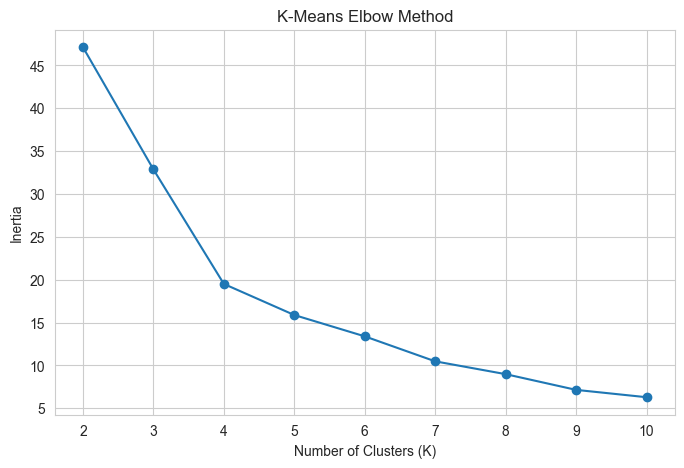

In [ ]:
#Plotting the results
plt.figure(figsize=(8, 5))
plt.plot(
    K_range,
    inertias,
    marker="o"
)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("K-Means Elbow Method")
plt.xticks(K_range)
plt.show()

In [ ]:
#From the grapph plotted above K appears to be 4, after 4 the curve decrease becomes gradual
#As such, Lets use K-Means with K=4
optimal_k = 4
kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)
kmeans_labels = kmeans.fit_predict(X_crime_pca)
USArrests["KMeans_Cluster"] = kmeans_labels
print(USArrests["KMeans_Cluster"].value_counts().sort_index())

KMeans_Cluster
0    14
1    12
2     7
3    17
Name: count, dtype: int64


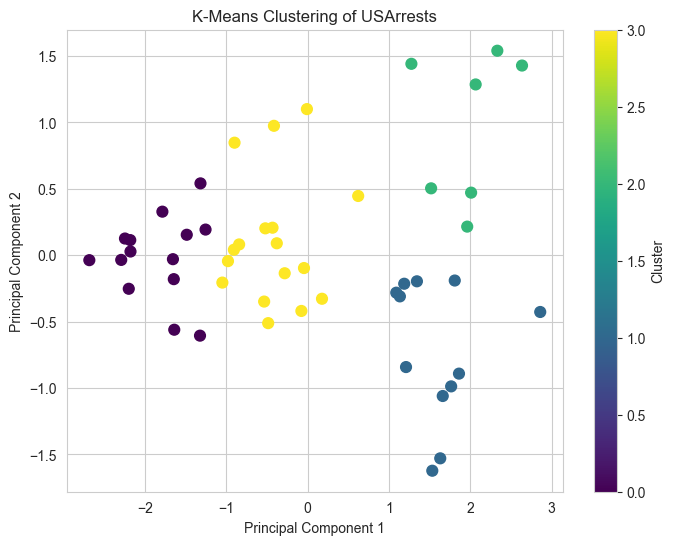

In [ ]:
#Visulaize K-Means
plt.figure(figsize=(8, 6))
plt.scatter(
    X_crime_pca[:, 0],
    X_crime_pca[:, 1],
    c=kmeans_labels,
    cmap="viridis",
    s=60
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering of USArrests")
plt.colorbar(label="Cluster")
plt.show()

In [ ]:
#Finding the best number of GMM clusters using BIC
bic_scores = []
for k in range(2, 11):
    gmm = GaussianMixture(
        n_components=k,
        random_state=42
    )  
    gmm.fit(X_crime_pca)
    bic_scores.append(gmm.bic(X_crime_pca))

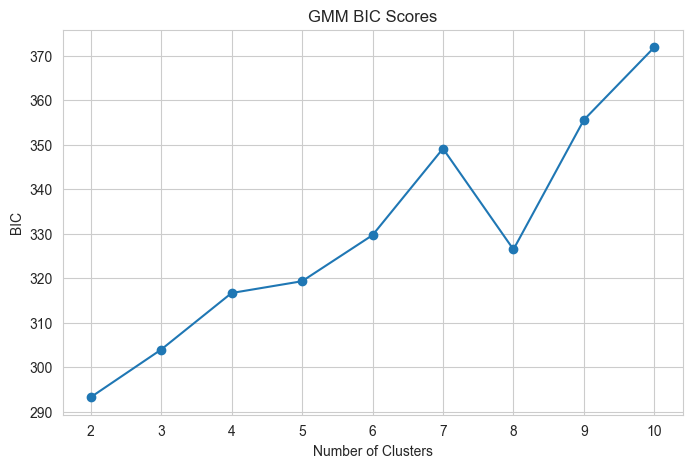

In [ ]:
#Plotting BIC
plt.figure(figsize=(8, 5))
plt.plot(
    range(2, 11),
    bic_scores,
    marker="o"
)
plt.xlabel("Number of Clusters")
plt.ylabel("BIC")
plt.title("GMM BIC Scores")
plt.show()

In [ ]:
#K=2, BIC values is at its lowest at 2 (Bayesian Information Criterion)-Optimal number of Gaussian Components for the GMM Model
#Fitting the GMM Model
gmm = GaussianMixture(
    n_components=2,
    random_state=42
)
gmm_labels = gmm.fit_predict(X_crime_pca)
USArrests["GMM_Cluster"] = gmm_labels
print(USArrests["GMM_Cluster"].value_counts().sort_index())

GMM_Cluster
0    31
1    19
Name: count, dtype: int64


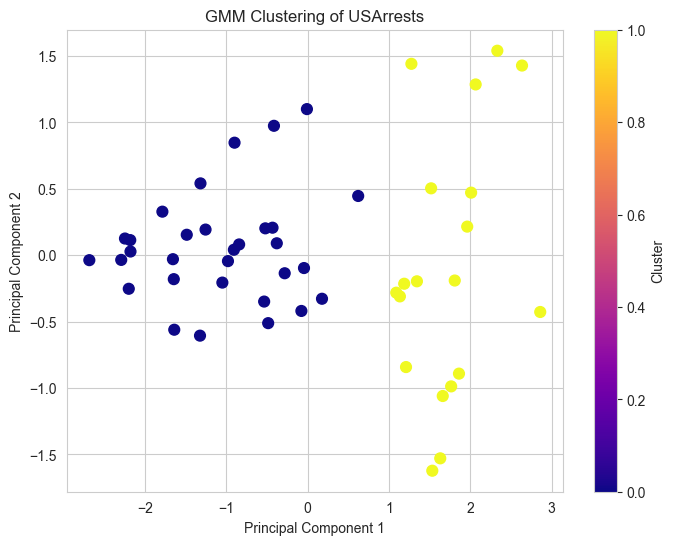

In [ ]:
#Visulaize GMM Model
plt.figure(figsize=(8, 6))
plt.scatter(
    X_crime_pca[:, 0],
    X_crime_pca[:, 1],
    c=gmm_labels,
    cmap="plasma",
    s=60
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("GMM Clustering of USArrests")
plt.colorbar(label="Cluster")
plt.show()

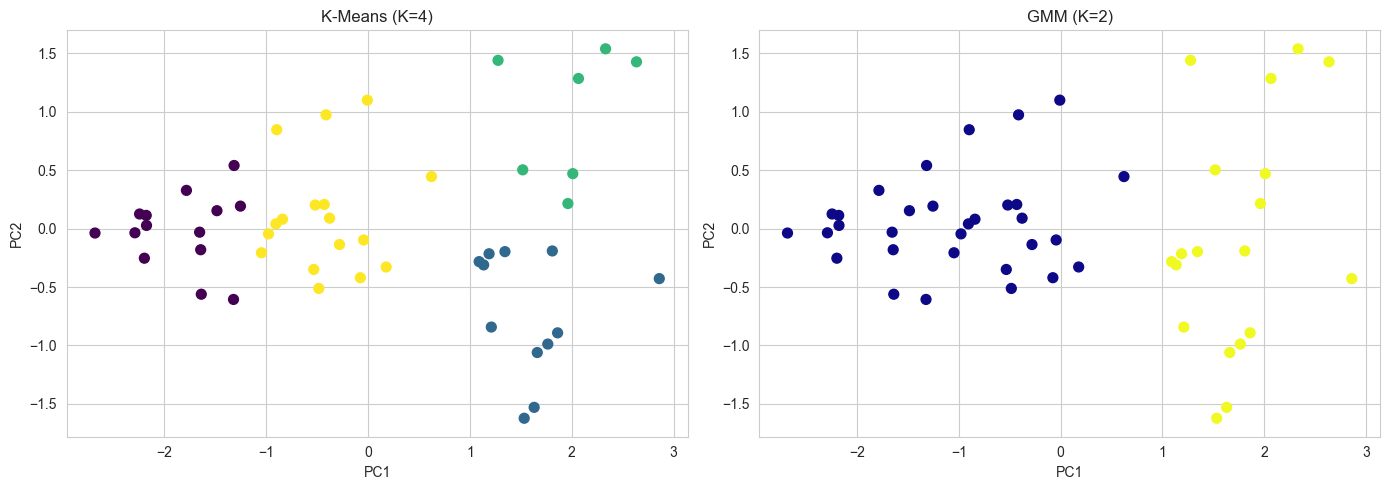

In [ ]:
#Comparing K-Means and GMM
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# K-Means
axes[0].scatter(
    X_crime_pca[:, 0],
    X_crime_pca[:, 1],
    c=kmeans_labels,
    cmap="viridis",
    s=50
)
axes[0].set_title("K-Means (K=4)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
# GMM
axes[1].scatter(
    X_crime_pca[:, 0],
    X_crime_pca[:, 1],
    c=gmm_labels,
    cmap="plasma",
    s=50
)
axes[1].set_title("GMM (K=2)")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
plt.tight_layout()
plt.show()

## USArrests Clustering Results & Interpretation

The USArrests dataset was standardized using three crime-related features: Murder, Assault, and Rape. PCA reduced these features to two principal components.

The K-Means elbow method indicated that 4 clusters provided a suitable grouping. K-Means was then used to assign each observation to one of four clusters.

For the Gaussian Mixture Model, BIC indicated that 2 clusters provided the best fit. Unlike K-Means, GMM provides probabilistic cluster assignments.

The two methods produced different groupings, showing that the crime data can be interpreted using different clustering approaches. K-Means provides clear hard cluster assignments, while GMM offers a probabilistic approach that can better represent uncertainty between groups.

## OVERALL EVALUATION AND CONCLUSION 

The three machine learning projects successfully addressed different business problems.

Wine Classification: PCA reduced 13 features to 10 while retaining 95% variance. GridSearchCV selected k=18 with Euclidean distance, achieving 97.91% cross-validation accuracy and 100% test accuracy.
Feed Recommendation: PCA reduced the standardized weight data to one component. Cosine similarity identified feeds with similar performance patterns.
Crime Clustering: PCA reduced three crime features to two components. K-Means identified 4 clusters using the elbow method, while GMM identified 2 clusters based on the lowest BIC.

Overall, the analysis demonstrates how classification, recommendation, PCA, and clustering techniques can provide useful insights for business decision-making.